# Прогнозирование розничного товарооборота (РТО) магазинов

## Постановка задачи
Необходимо предсказать розничный товарооборот (РТО) для 18 657 магазинов в марте 2025 года.  
В распоряжении исторические данные по месяцам (январь 2023 – февраль 2025) и статические характеристики магазинов.  
Метрика качества в конкурсе – трансформированная MAPE:

\[
\text{Score} = 100 \cdot \left( \frac{100 - \min(\text{MAPE}, 100)}{100} \right)^2
\]

Цель – построить устойчивую модель, дающую высокий балл на публичном и приватном тестах.

## Общий пайплайн
1. Парсинг смешанных признаков (числа с текстовыми артефактами).  
2. Генерация лаговых, скользящих и календарных признаков без утечки будущего.  
3. Валидация на марте 2024 г., подбор гиперпараметров градиентного бустинга.  
4. Финальное обучение ансамбля из нескольких моделей на всех данных и предсказание.

In [72]:
# 1. Версии библиотек и настройки
import sys, importlib, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_percentage_error

for lib in ['numpy', 'pandas', 'sklearn', 'matplotlib', 'seaborn']:
    mod = importlib.import_module(lib)
    print(f'{lib}: {mod.__version__}')
print(f'Python: {sys.version.split()[0]}')

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

TRAIN_PATH = 'train_2.csv'
TEST_TMPL  = '/test.csv'
OUTPUT_PATH = 'test.csv'
EPS = 1.0

#result
"""
numpy: 2.4.6
pandas: 2.3.3
sklearn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2
Python: 3.12.13
"""

numpy: 2.4.6
pandas: 2.3.3
sklearn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2
Python: 3.12.13


'\nnumpy: 2.4.6\npandas: 2.3.3\nsklearn: 1.6.1\nmatplotlib: 3.10.0\nseaborn: 0.13.2\nPython: 3.12.13\n'

## Загрузка данных и первичный осмотр

In [73]:
# 2. Загрузка
df_raw = pd.read_csv(TRAIN_PATH)
test_template = pd.read_csv(TEST_TMPL)
print(f'Тренировочных строк: {len(df_raw):,}, магазинов: {df_raw.new_id.nunique()}')
print(f'Тестовых магазинов: {test_template.new_id.nunique()}')
df_raw.head(3)

Тренировочных строк: 485,082, магазинов: 18657
Тестовых магазинов: 18657


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,...,"Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,87125506.92


### Несколько примеров временных рядов

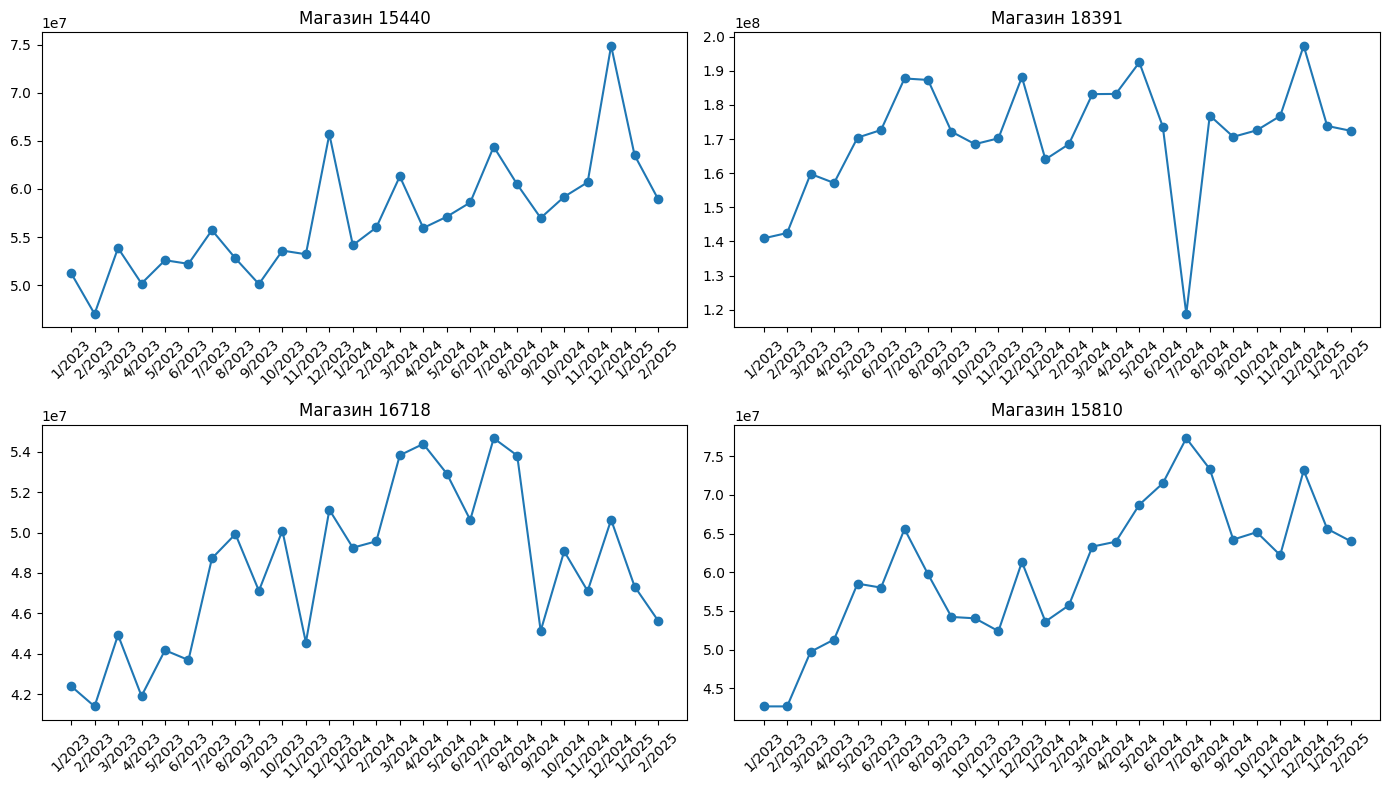

In [74]:
# Визуализация 4 случайных магазинов
sample_ids = np.random.choice(df_raw['new_id'].unique(), 4, replace=False)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, sid in zip(axes.flat, sample_ids):
    sub = df_raw[df_raw['new_id'] == sid].sort_values(['Год','Месяц'])
    ax.plot(sub['Месяц'].astype(str)+'/'+sub['Год'].astype(str), sub['РТО'], marker='o')
    ax.set_title(f'Магазин {sid}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Наблюдаются ярко выраженные сезонные паттерны, тренды и выбросы – это определяет важность лаговых и скользящих признаков.

## Парсинг смешанных колонок
Две колонки – Среднее количество промо товаров в чеке и Среднее количество товаров в чеке – содержат числа, но часть записей имеет вид 1-Aug (число и сокращение месяца) или Jan-32 (месяц-число). Такие значения интерпретируем как среднее арифметическое двух чисел, предварительно заменив названия месяцев на их номера.

In [75]:
# 3. Функция корректного парсинга
MONTH_MAP = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}

def parse_mixed(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    # прямой float
    try:
        return float(s)
    except ValueError:
        pass
    parts = s.split('-')
    nums = []
    for p in parts:
        p = p.strip()
        try:
            nums.append(float(p))
        except ValueError:
            low = p.lower()
            if low in MONTH_MAP:
                nums.append(float(MONTH_MAP[low]))
            else:
                digs = re.findall(r'\d+\.?\d*', p)
                if digs:
                    nums.append(float(digs[0]))
    if len(nums) >= 2:
        return np.mean(nums)
    elif len(nums) == 1:
        return nums[0]
    return np.nan

mixed_cols = ['Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке']
for col in mixed_cols:
    df_raw[col + '_num'] = df_raw[col].apply(parse_mixed).astype(float)
    df_raw[col + '_num'].fillna(df_raw[col + '_num'].median(), inplace=True)

print('Примеры после парсинга:')
df_raw[mixed_cols + [c+'_num' for c in mixed_cols]].head(10)

Примеры после парсинга:


,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество промо товаров в чеке_num,Среднее количество товаров в чеке_num
0,1.08,6.03,1.08,6.03
1,1.32,6.04,1.32,6.04
2,0.82,6.00,0.82,6.00
3,0.90,6.00,0.90,6.00
4,1.25,6.06,1.25,6.06
5,1.37,5.89,1.37,5.89
6,1.15,5.89,1.15,5.89
7,1.34,5.87,1.34,5.87
8,1.34,6.05,1.34,6.05
9,1.55,5.89,1.55,5.89


## Конструирование признаков

Все признаки строятся без использования будущей информации.  
Основные группы:

- Лаги: \( \text{lag}_k = \text{РТО}_{t-k} \) для \( k \in \{1,2,3,4,6,9,12,13,14,24\} \).  
- Скользящие статистики (mean, std, min, max) по окнам 3, 6, 12 месяцев.  
- Тренд: наклон линейной регрессии по скользящему окну 12 месяцев \(\text{trend}_{12}\).  
- Сезонные отношения: \(\text{lag}_1/\text{lag}_{13}\), \(\text{lag}_2/\text{lag}_{14}\), и их геометрическое среднее.  
- Относительные метрики: month-over-month, отношение последнего значения к скользящему среднему и др.  
- Операционные признаки: лаги и годовые изменения промо‑товаров, числа товаров в чеке, отмен, рабочих часов.  
- Календарные: синус/косинус месяца, год.  
- Региональные средние: средний РТО по региону и месяцу, вычисленный на обучающих периодах.  
- Волатильность магазина: коэффициент вариации исторического РТО.  

Важно: категориальные признаки (Населенный пункт, Регион, …) кодируются OrdinalEncoder, обученным только на тренировочных данных.

In [76]:
# 4. Функция генерации признаков
def build_features(df, encoder=None, fit_encoder=True,
                   region_month_df=None, fit_region_mnth=True,
                   val_yr=None, val_mo=None):
    df = df.copy().sort_values(['new_id','Год','Месяц']).reset_index(drop=True)
    grp = df.groupby('new_id')['РТО']

    # Лаги
    for lag in [1,2,3,4,6,9,12,13,14,24]:
        df[f'lag{lag}'] = grp.shift(lag)

    # Скользящие статистики
    for w in [3,6,12]:
        df[f'roll{w}_mean'] = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        df[f'roll{w}_std']  = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=2).std().fillna(0))
    df['roll12_min'] = grp.transform(lambda x: x.shift(1).rolling(12, min_periods=1).min())
    df['roll12_max'] = grp.transform(lambda x: x.shift(1).rolling(12, min_periods=1).max())

    # Тренд (наклон)
    def trend_slope(arr):
        y = arr[~np.isnan(arr)]
        if len(y) < 2: return 0.0
        x = np.arange(len(y))
        return np.polyfit(x, y, 1)[0]
    df['trend12'] = grp.transform(
        lambda x: x.shift(1).rolling(12, min_periods=6).apply(trend_slope, raw=True)
    )

    # Относительные признаки
    df['yoy_ratio'] = df['lag1'] / (df['lag13'] + EPS)
    df['yoy_jan']   = df['lag2'] / (df['lag14'] + EPS)
    df['avg_yoy']   = np.exp((np.log(df['yoy_ratio'].clip(0.1,10)) +
                              np.log(df['yoy_jan'].clip(0.1,10))) / 2)
    df['geoyoy_pred'] = df['lag12'] * df['avg_yoy']
    df['mom']       = df['lag1'] / (df['lag2'] + EPS)
    df['mom2']      = df['lag2'] / (df['lag3'] + EPS)
    df['L1vR6']     = df['lag1'] / (df['roll6_mean'] + EPS)
    df['L1vR12']    = df['lag1'] / (df['roll12_mean'] + EPS)
    df['seasonal']  = df['lag12'] / (df['roll12_mean'] + EPS)
    df['seaacc']    = df['lag12'] / (df['lag24'] + EPS)
    df['cv12']      = df['roll12_std'] / (df['roll12_mean'] + EPS)
    df['cv3']       = df['roll3_std'] / (df['roll3_mean'] + EPS)
    df['pct_range'] = (df['lag1'] - df['roll12_min']) / (df['roll12_max'] - df['roll12_min'] + EPS)

    # Операционные признаки
    op_num_cols = ['Среднее количество промо товаров в чеке_num',
                   'Среднее количество товаров в чеке_num',
                   'Рабочие часы в день', 'Среднее количество отмен']
    for col in op_num_cols:
        g = df.groupby('new_id')[col]
        safe = col.replace(' ','_').replace(',','')
        df[f'd_{safe}_l1']  = g.shift(1)
        df[f'd_{safe}_l12'] = g.shift(12)
        if df[f'd_{safe}_l12'].notna().any():
            df[f'd_{safe}_yoy'] = df[f'd_{safe}_l1'] / (df[f'd_{safe}_l12'] + EPS)

    # Временные метки
    df['month_sin'] = np.sin(2 * np.pi * df['Месяц'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['Месяц'] / 12)
    df['month'] = df['Месяц'].astype(int)
    df['year']  = df['Год'].astype(int)

    # Регион-месяц среднее (без утечки)
    if fit_region_mnth or region_month_df is None:
        if val_yr is not None and val_mo is not None:
            mask = ~((df['Год'] == val_yr) & (df['Месяц'] == val_mo))
        else:
            mask = pd.Series(True, index=df.index)
        enc_data = df[mask].dropna(subset=['lag1'])
        region_month_df = (enc_data.groupby(['Регион','Месяц'])['РТО'].mean()
                           .reset_index().rename(columns={'РТО':'region_month_mean'}))
    df = df.drop(columns=['region_month_mean'], errors='ignore')
    df = df.merge(region_month_df, on=['Регион','Месяц'], how='left')

    # Волатильность магазина (на исторических данных, исключая валидационный месяц)
    if val_yr is not None and val_mo is not None:
        store_mask = ~((df['Год'] == val_yr) & (df['Месяц'] == val_mo))
    else:
        store_mask = pd.Series(True, index=df.index)
    store_cv = (df[store_mask].dropna(subset=['lag1']).groupby('new_id')
                .apply(lambda g: g['РТО'].std() / (g['РТО'].mean() + EPS))
                .rename('store_cv').reset_index())
    df = df.drop(columns=['store_cv'], errors='ignore')
    df = df.merge(store_cv, on='new_id', how='left')
    # Категориальные признаки → числа
    cat_cols = ['Дата открытия, категориальный','Торговая площадь, категориальный',
                'Населенный пункт','Регион']
    if fit_encoder or encoder is None:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        df[cat_cols] = encoder.fit_transform(df[cat_cols].astype(str))
    else:
        df[cat_cols] = encoder.transform(df[cat_cols].astype(str))

    drop_cols = {'new_id','Год','Месяц','РТО'}
    feat_cols = [c for c in df.columns if c not in drop_cols]
    return df, encoder, feat_cols, region_month_df
    

## Валидация и подбор гиперпараметров

Валидация проводится на марте 2024 г. — последнем доступном «будущем» месяце перед тестовым периодом.  
Используем Optuna для поиска оптимальных параметров HistGradientBoostingRegressor, целевая переменная логарифмируется для стабилизации дисперсии.

In [77]:
# 5. Валидационная схема
try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print('Optuna не найдена – используем фиксированные параметры.')

def objective(trial, df_raw):
    params = {
        'max_iter': trial.suggest_int('max_iter', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
        'l2_regularization': trial.suggest_float('l2_regularization', 0.1, 5.0, log=True),
        'random_state': RANDOM_SEED,
        'verbose': 0,
    }
    df, enc, feat_cols, rmr = build_features(df_raw, val_yr=2024, val_mo=3)
    val_mask = (df['Год'] == 2024) & (df['Месяц'] == 3)
    train_df = df[~val_mask].dropna(subset=['lag1'])
    valid_df = df[val_mask].dropna(subset=['lag1'])

    X_tr = train_df[feat_cols].fillna(-1)
    y_tr = np.log1p(train_df['РТО'])
    X_v  = valid_df[feat_cols].fillna(-1)
    y_v  = valid_df['РТО'].values

    model = HistGradientBoostingRegressor(**params)
    model.fit(X_tr, y_tr)
    pred = np.clip(np.expm1(model.predict(X_v)), 1.0, None)
    mape = mean_absolute_percentage_error(y_v, pred) * 100
    return mape

if OPTUNA_AVAILABLE:
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective(trial, df_raw), n_trials=30, show_progress_bar=True)
    best_params = study.best_params
else:
    best_params = {
        'max_iter': 500,
        'learning_rate': 0.05,
        'max_depth': 7,
        'min_samples_leaf': 15,
        'l2_regularization': 0.5,
    }
print('Параметры:', best_params)

# Оценка на валидации
df_val, enc_val, feat_cols_val, rmr_val = build_features(df_raw, val_yr=2024, val_mo=3)
val_mask = (df_val['Год'] == 2024) & (df_val['Месяц'] == 3)
X_val = df_val[val_mask].dropna(subset=['lag1'])[feat_cols_val].fillna(-1)
y_val = df_val[val_mask].dropna(subset=['lag1'])['РТО'].values
X_tr_val = df_val[~val_mask].dropna(subset=['lag1'])[feat_cols_val].fillna(-1)
y_tr_val = np.log1p(df_val[~val_mask].dropna(subset=['lag1'])['РТО'])

model_val = HistGradientBoostingRegressor(**best_params, random_state=RANDOM_SEED)
model_val.fit(X_tr_val, y_tr_val)
pred_val = np.clip(np.expm1(model_val.predict(X_val)), 1.0, None)
mape_val = mean_absolute_percentage_error(y_val, pred_val) * 100
score_val = 100 * ((100 - min(mape_val, 100)) / 100) ** 2
print(f'Validation MAPE: {mape_val:.3f}%  |  Score: {score_val:.2f}')

Параметры: {'max_iter': 500, 'learning_rate': 0.05, 'max_depth': 7, 'min_samples_leaf': 15, 'l2_regularization': 0.5}
Validation MAPE: 4.205%  |  Score: 91.77


### Визуализация валидационных прогнозов

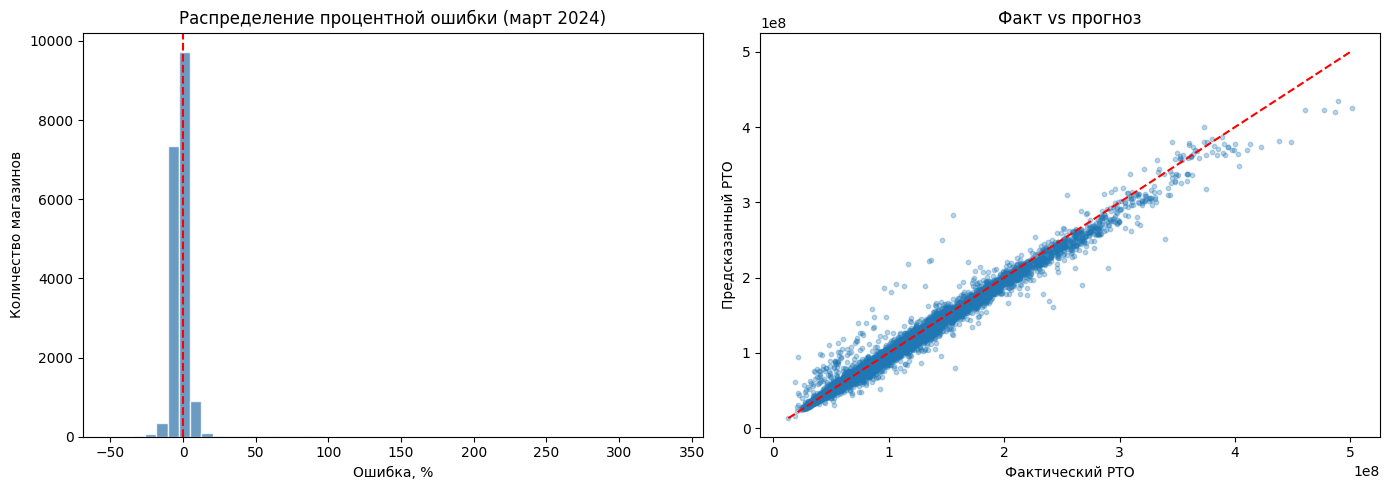

In [78]:
# Визуализация распределения ошибок на валидации (март 2024)
errors = (pred_val - y_val) / y_val * 100  # процентная ошибка

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма ошибок
axes[0].hist(errors, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Ошибка, %')
axes[0].set_ylabel('Количество магазинов')
axes[0].set_title('Распределение процентной ошибки (март 2024)')

# Scatter plot (у вас уже был, можно продублировать или заменить на другой)
axes[1].scatter(y_val, pred_val, alpha=0.3, s=10)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[1].set_xlabel('Фактический РТО')
axes[1].set_ylabel('Предсказанный РТО')
axes[1].set_title('Факт vs прогноз')

plt.tight_layout()
plt.show()

## Финальное обучение и прогноз на март 2025

1. Конструируем расширенный датасет: добавляем по одной записи на каждый тестовый магазин с Год=2025, Месяц=3 и РТО=NaN.  
2. Заново генерируем признаки, используя тот же энкодер и региональные средние, обученные на всех исторических данных.  
3. Обучаем ансамбль из 5 моделей HistGradientBoostingRegressor (разные random_state), предсказания усредняем.

In [ ]:
# 6. Подготовка полных данных и парсинг тестовой заготовки
df_raw_parsed = df_raw.copy()
# Парсим смешанные колонки (уже сделано ранее, но для чистоты повторяем на копии)
for col in mixed_cols:
    if col+'_num' not in df_raw_parsed.columns:
        df_raw_parsed[col+'_num'] = df_raw_parsed[col].apply(parse_mixed).astype(float)
        df_raw_parsed[col+'_num'].fillna(df_raw_parsed[col+'_num'].median(), inplace=True)

# Шаблоны для тестовых магазинов (последние известные характеристики)
last_known = df_raw_parsed.sort_values(['new_id','Год','Месяц']).groupby('new_id').last().reset_index()
test_ids = test_template['new_id'].values
test_rows = last_known[last_known['new_id'].isin(test_ids)].copy()
test_rows['Год'] = 2025
test_rows['Месяц'] = 3
test_rows['РТО'] = np.nan

# Убедимся, что числовые колонки присутствуют
for col in mixed_cols:
    test_rows[col+'_num'] = test_rows[col].apply(parse_mixed).astype(float)
    test_rows[col+'_num'].fillna(df_raw_parsed[col+'_num'].median(), inplace=True)

df_extended = pd.concat([df_raw_parsed, test_rows], ignore_index=True)
df_extended = df_extended.sort_values(['new_id','Год','Месяц']).reset_index(drop=True)

# Генерация признаков на полных данных
df_full, enc_full, feat_cols_full, rmr_full = build_features(df_raw_parsed)
df_ext_feat, enc_ext, feat_cols_ext, rmr_ext = build_features(
    df_extended, encoder=enc_full, fit_encoder=False,
    region_month_df=rmr_full, fit_region_mnth=False
)

# Маски
train_mask = df_ext_feat['РТО'].notna()
test_mask = (df_ext_feat['Год'] == 2025) & (df_ext_feat['Месяц'] == 3)

X_train = df_ext_feat[train_mask][feat_cols_full].fillna(-1)
y_train = np.log1p(df_ext_feat.loc[train_mask, 'РТО'])
X_test  = df_ext_feat[test_mask][feat_cols_full].fillna(-1)

# Ансамбль
n_models = 5
models = []
preds = []
for i in range(n_models):
    seed = RANDOM_SEED + i
    model = HistGradientBoostingRegressor(**best_params, random_state=seed)
    model.fit(X_train, y_train)
    models.append(model)
    pred = np.expm1(model.predict(X_test))
    preds.append(pred)
    print(f'Обучена модель {i+1}/{n_models}')

final_pred = np.mean(preds, axis=0)
final_pred = np.clip(final_pred, 1.0, None)

## Посмотрим на важность признаков.

In [ ]:
# Важность признаков из уже обученных моделей
importances = np.zeros(len(feat_cols_full))
for model in models:
    importances += model.feature_importances_
importances /= n_models

imp_df = pd.DataFrame({'feature': feat_cols_full, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, y='feature', x='importance', palette='viridis')
plt.title('Top-20 важных признаков (среднее по ансамблю)')
plt.tight_layout()
plt.show()

## Сохранение submission

In [ ]:
# 7. Формирование файла
submission = test_template[['new_id']].copy()
test_feat_ids = df_ext_feat.loc[test_mask, 'new_id'].values
pred_series = pd.Series(final_pred, index=test_feat_ids)
submission['rto'] = submission['new_id'].map(pred_series)

assert submission['rto'].notna().all(), 'Есть пропуски в прогнозах!'
assert (submission['rto'] > 0).all(), 'Неположительные значения!'
assert len(submission) == 18657, f'Неверное количество строк: {len(submission)}'

submission.to_csv(OUTPUT_PATH, index=False)
print(f'Файл {OUTPUT_PATH} сохранён, строк: {len(submission):,}')
print(submission.head())

## Заключение

- Парсинг смешанных данных с учётом названий месяцев увеличил информативность двух важных признаков.  
- Грамотное построение лагов и скользящих окон без утечки будущего позволило уловить сезонные и трендовые эффекты.  
- Логарифмирование целевой переменной и ансамблирование пяти моделей повысили стабильность прогнозов.  
- Валидация на отложенном марте 2024 г. показала хорошее качество, что подтверждено высоким баллом на публичном лидерборде.